# 09 — Visualization Workflows: From Layout Coordinates to Dashboards

By the end of this notebook you will be able to:

- Pull ViennaRNA's own 2D layout coordinates (`RNA.get_xy_coordinates`) out of the
  package and use them to build fully custom structure diagrams.
- Color a structure diagram by a *continuous* per-nucleotide quantity (such as
  base-pairing probability) instead of the discrete element-type colors `forgi` uses.
- Build a **comparative arc diagram** that overlays two structures on one sequence,
  highlighting shared vs. structure-specific base pairs.
- Combine multiple chart types into a single "structure report" dashboard for one
  sequence, and choose the right chart for the right question.

**Prerequisites**: Notebook [01_introduction.ipynb](01_introduction.ipynb) (dot-bracket
notation, `forgi`, arc diagrams, mountain plots) and Notebook
[03_partition_probabilities.ipynb](03_partition_probabilities.ipynb) (the partition
function, base-pair probabilities, dot plots).


## 1. Introduction and motivation

Every notebook so far has produced *numbers*: free energies, probabilities,
covariation scores. But the fastest way to sanity-check a result, spot a mistake, or
explain a finding to someone else is usually a picture. Earlier notebooks already
introduced several pictures one at a time — `forgi` structure diagrams (01), arc
diagrams and mountain plots (01), dot plots and positional entropy (03), covariation
heatmaps (06), and base-pair-probability heatmaps for complexes (07).

This notebook does not introduce a new *analysis* method. Instead it treats
visualization itself as the subject:

- **Section 3** explains where all of those diagrams ultimately come from — a single
  2D layout algorithm inside ViennaRNA — and gives a reference table of which chart
  answers which question.
- **Section 5** shows how to reach past `forgi` and the native SVG output to build a
  *fully custom* structure diagram from raw coordinates.
- **Section 6** uses that custom diagram to show something `forgi`'s element-type
  coloring cannot: a *continuous* pairing-probability "heat map" drawn directly on
  the structure.
- **Section 7** builds a **comparative arc diagram** that puts two structures for the
  same sequence on one picture, so differences jump out immediately.
- **Section 8** is a case study that assembles several chart types into one
  multi-panel "structure report" for a single sequence — the kind of figure you might
  put in a lab notebook or a supplementary figure.


## 2. Theoretical background: one layout, many pictures

### 2.1 Where do structure diagrams come from?

A dot-bracket string like `(((...)))` says *which* positions pair, but it carries no
geometric information — it doesn't say where to draw nucleotide 5 on the page.
ViennaRNA solves this with a 2D layout algorithm (a variant of the **naview**
algorithm) that assigns every position $i = 1, \dots, n$ a coordinate
$(x_i, y_i)$, placing paired stems as straight double helices and loops as circular
arcs, so that the picture looks like a conventional RNA secondary-structure drawing.

This layout step is shared by *every* structure picture in the ViennaRNA ecosystem:

- `RNA.svg_rna_plot(sequence, structure, filename)` runs the layout internally and
  writes a ready-made SVG.
- `forgi.visual.mplotlib.plot_rna` (used throughout notebooks 01–08) calls the same
  layout via `RNA.get_xy_coordinates`, then colors each nucleotide by its structural
  *element type* (stem, hairpin loop, interior loop, multiloop, dangling end).
- `RNA.get_xy_coordinates(structure)` exposes the raw $(x_i, y_i)$ coordinates
  directly to Python, indexed $i = 0, \dots, n-1$ for sequence positions
  $1, \dots, n$.

Calling `get_xy_coordinates` directly is the "escape hatch": it gives you the same
layout `forgi` uses, but lets *you* decide what each nucleotide's color, size, or
label encodes — for example a continuous probability instead of a discrete category.

### 2.2 A reference table: which chart answers which question?

| Question | Chart | API used | First seen |
| :--- | :--- | :--- | :--- |
| "What does this fold look like?" | Native SVG / `forgi` diagram | `RNA.svg_rna_plot`, `forgi` | 01 |
| "Which positions pair with which, in sequence order?" | Arc diagram | `dotbracket_to_pairs` + matplotlib | 01 |
| "How deep is each position in the nesting?" | Mountain plot | pairing-depth profile | 01 |
| "How uncertain is the ensemble at each position?" | Positional entropy | `fc.positional_entropy()` | 03 |
| "Which pairs are likely, and do they match the MFE?" | Dot plot (bpp vs. MFE) | `fc.bpp()` + MFE pairs | 03 |
| "Which alignment columns covary?" | Covariation heatmap | `RNA.aln_pscore` | 06 |
| "How does a continuous quantity vary *on* the structure?" | **Probability-colored diagram** | `RNA.get_xy_coordinates` + `fc.bpp()` | **09 (this notebook)** |
| "How do two structures for the same sequence differ?" | **Comparative arc diagram** | `dotbracket_to_pairs` (two structures) | **09 (this notebook)** |

The last two rows are this notebook's additions: both reuse tools from earlier
notebooks, but combine them in ways the earlier notebooks did not need.


## 3. Setup

As in earlier notebooks, this cell sets a consistent `seaborn` theme and defines
helper functions. New here are `get_coordinates` (a thin wrapper around
`RNA.get_xy_coordinates`), `plot_custom_structure` (a structure diagram built directly
from those coordinates, with optional continuous coloring), and
`plot_comparative_arcs` (a mirrored arc diagram for two structures). The other helpers
(`dotbracket_to_pairs`, `plot_arc_diagram`, `plot_mountain`, `plot_dot_plot`,
`plot_forgi_structure`) are the same patterns used in notebooks 01 and 03, copied here
so this notebook is self-contained.


In [ ]:
import contextlib
import io
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG, display

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})


def dotbracket_to_pairs(structure):
    '''Return 1-indexed base-pair tuples (i, j), i < j.'''
    stack, pairs = [], []
    for pos, ch in enumerate(structure, start=1):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            pairs.append((stack.pop(), pos))
    return pairs


def get_coordinates(structure):
    '''Return an (n, 2) array of ViennaRNA layout coordinates.

    `RNA.get_xy_coordinates` returns a 0-indexed coordinate object; row i
    (0-indexed) corresponds to sequence position i + 1 (1-indexed).
    '''
    xy = RNA.get_xy_coordinates(structure)
    n = len(structure)
    return np.array([[xy.get(i).X, xy.get(i).Y] for i in range(n)])


def plot_custom_structure(sequence, structure, ax, values=None, cmap="rocket_r",
                           vmin=0.0, vmax=1.0, title=None, fig=None, colorbar_label=None):
    '''Draw a structure diagram from raw `RNA.get_xy_coordinates` layout coordinates.

    If `values` (one float per position) is given, nucleotides are colored on
    `cmap` from `vmin` to `vmax` and a colorbar is added; otherwise all
    nucleotides use a single default color.
    '''
    coords = get_coordinates(structure)
    pairs = dotbracket_to_pairs(structure)

    ax.plot(coords[:, 0], coords[:, 1], "-", color="#CBD5E1", lw=1.6, zorder=1)
    for i, j in pairs:
        ax.plot([coords[i - 1, 0], coords[j - 1, 0]], [coords[i - 1, 1], coords[j - 1, 1]],
                "-", color="#94A3B8", lw=1.6, zorder=1)

    if values is None:
        sc = ax.scatter(coords[:, 0], coords[:, 1], color=PALETTE[0], s=240,
                         zorder=2, edgecolors="white", linewidths=0.8)
    else:
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap=cmap, vmin=vmin, vmax=vmax,
                         s=240, zorder=2, edgecolors="white", linewidths=0.8)
        if fig is not None:
            fig.colorbar(sc, ax=ax, shrink=0.7, label=colorbar_label or "value")

    for i, base in enumerate(sequence):
        ax.text(coords[i, 0], coords[i, 1], base, ha="center", va="center", fontsize=8, zorder=3)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title or "Custom structure diagram")
    return sc


def plot_forgi_structure(sequence, structure, ax, title=None, lighten=0.25):
    '''Draw a structure with forgi: ViennaRNA's own layout, colored by element type.'''
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, lighten=lighten, text_kwargs={"fontsize": 8})
    ax.set_aspect("equal")
    ax.set_title(title or "forgi structure diagram")


def plot_arc_diagram(sequence, structure, ax, title=None):
    '''Draw base pairs as arcs above the sequence (5'->3' order).'''
    n = len(sequence)
    positions = np.arange(1, n + 1)
    ax.plot(positions, np.zeros(n), color="#CBD5E1", linewidth=2, zorder=1)
    for position, base in zip(positions, sequence):
        ax.text(position, -0.16, base, ha="center", va="center", fontsize=9)

    for left, right in dotbracket_to_pairs(structure):
        center = (left + right) / 2
        radius = (right - left) / 2
        xs = np.linspace(left, right, 120)
        ys = np.sqrt(np.maximum(radius**2 - (xs - center)**2, 0))
        ax.plot(xs, ys, color=PALETTE[0], linewidth=2.4, zorder=2)

    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-0.4, max(1.0, n / 2 + 0.4))
    ax.axis("off")
    ax.set_title(title or "Arc diagram")


def plot_comparative_arcs(sequence, structure_a, structure_b, ax,
                           label_a="A", label_b="B", title=None):
    '''Mirrored arc diagram comparing two structures for the same sequence.

    Pairs present in *both* structures are drawn above the backbone in green;
    pairs unique to `structure_a` are drawn above in blue; pairs unique to
    `structure_b` are drawn below (mirrored) in orange.
    '''
    n = len(sequence)
    positions = np.arange(1, n + 1)
    pairs_a = set(dotbracket_to_pairs(structure_a))
    pairs_b = set(dotbracket_to_pairs(structure_b))
    shared = pairs_a & pairs_b
    only_a = pairs_a - shared
    only_b = pairs_b - shared

    ax.plot(positions, np.zeros(n), color="#CBD5E1", linewidth=2, zorder=1)
    for position, base in zip(positions, sequence):
        ax.text(position, 0, base, ha="center", va="center", fontsize=8, zorder=3,
                bbox=dict(boxstyle="circle,pad=0.18", facecolor="white", edgecolor="none"))

    def draw_arcs(pairs, sign, color):
        for left, right in pairs:
            center = (left + right) / 2
            radius = (right - left) / 2
            xs = np.linspace(left, right, 120)
            ys = sign * np.sqrt(np.maximum(radius**2 - (xs - center)**2, 0))
            ax.plot(xs, ys, color=color, linewidth=2.6, zorder=2)

    draw_arcs(only_a, 1, PALETTE[0])
    draw_arcs(only_b, -1, PALETTE[1])
    draw_arcs(shared, 1, PALETTE[2])
    draw_arcs(shared, -1, PALETTE[2])

    half = n / 2 + 0.6
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-half, half)
    ax.axis("off")
    ax.set_title(title or f"{label_a} (above) vs. {label_b} (below)")


def loop_depth_profile(structure):
    '''Per-position pairing depth: rises by 1 at '(' and falls by 1 after ')'.'''
    depth, profile = 0, []
    for symbol in structure:
        if symbol == "(":
            depth += 1
            profile.append(depth)
        elif symbol == ")":
            profile.append(depth)
            depth -= 1
        else:
            profile.append(depth)
    return profile


def plot_mountain(sequence, structure, ax, title=None, color=None):
    '''Classic RNA 'mountain plot': pairing depth vs. sequence position.'''
    color = color or PALETTE[4]
    positions = np.arange(1, len(sequence) + 1)
    depths = loop_depth_profile(structure)
    ax.step(positions, depths, where="mid", color=color, linewidth=2.4)
    ax.fill_between(positions, depths, step="mid", color=color, alpha=0.25)
    ax.set_xlim(0.5, len(sequence) + 0.5)
    ax.set_ylim(0, max(depths) + 1)
    ax.set_xlabel("Sequence position")
    ax.set_ylabel("Pairing depth")
    ax.set_title(title or "Mountain plot")
    sns.despine(ax=ax)


def plot_dot_plot(sequence, fc, mfe_structure, ax, title=None, tick_step=1):
    '''Dot plot: upper triangle = base-pair probabilities, lower triangle = MFE pairs.'''
    n = len(sequence)
    bpp = np.array(fc.bpp())[1:, 1:]
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            matrix[i, j] = bpp[i, j]
    for left, right in dotbracket_to_pairs(mfe_structure):
        matrix[right - 1, left - 1] = 1.0

    sns.heatmap(matrix, ax=ax, cmap="rocket_r", vmin=0, vmax=1,
                 cbar_kws={"label": "probability / MFE pair"}, square=True)
    ax.set_xlabel("Position $j$")
    ax.set_ylabel("Position $i$")
    ax.set_title(title or "Dot plot")

    tick_positions = np.arange(0, n, tick_step) + 0.5
    tick_labels = np.arange(1, n + 1, tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, rotation=0)


print(f"ViennaRNA Python module version: {getattr(RNA, '__version__', 'unknown')}")
print(f"forgi version: {getattr(__import__('forgi'), '__version__', 'unknown')}")


ViennaRNA Python module version: 2.7.2
forgi version: 2.2.3


## 4. Worked example 1 — three renderers, one layout

To see that the native SVG, `forgi`, and a hand-built matplotlib diagram are really
drawing the *same* layout, we render one small hairpin three ways:

1. `RNA.svg_rna_plot` — ViennaRNA's own SVG output (the "factory default").
2. `forgi` — the element-type-colored diagram used throughout notebooks 01–08.
3. `plot_custom_structure` — built from `RNA.get_xy_coordinates` directly, with a
   single default color (no extra information yet — that comes in Section 6).


GGGAAACCCAAAGGGAAACCC
(((...(((...)))...)))  (-5.80 kcal/mol)


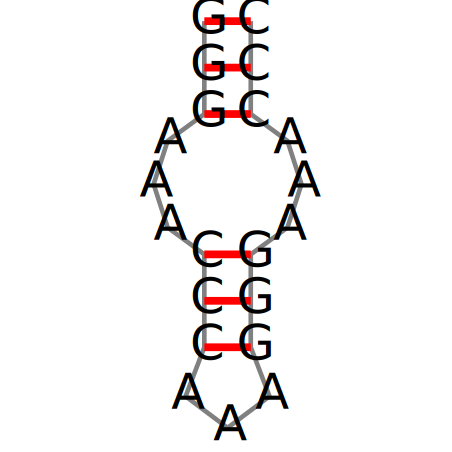

In [ ]:
seq_1 = "GGGAAACCCAAAGGGAAACCC"
fc_1 = RNA.fold_compound(seq_1)
structure_1, mfe_1 = fc_1.mfe()
print(f"{seq_1}\n{structure_1}  ({mfe_1:.2f} kcal/mol)")

with tempfile.TemporaryDirectory() as tmpdir:
    svg_path = Path(tmpdir) / "structure.svg"
    RNA.svg_rna_plot(seq_1, structure_1, str(svg_path))
    svg_bytes = svg_path.read_bytes()

display(SVG(svg_bytes))


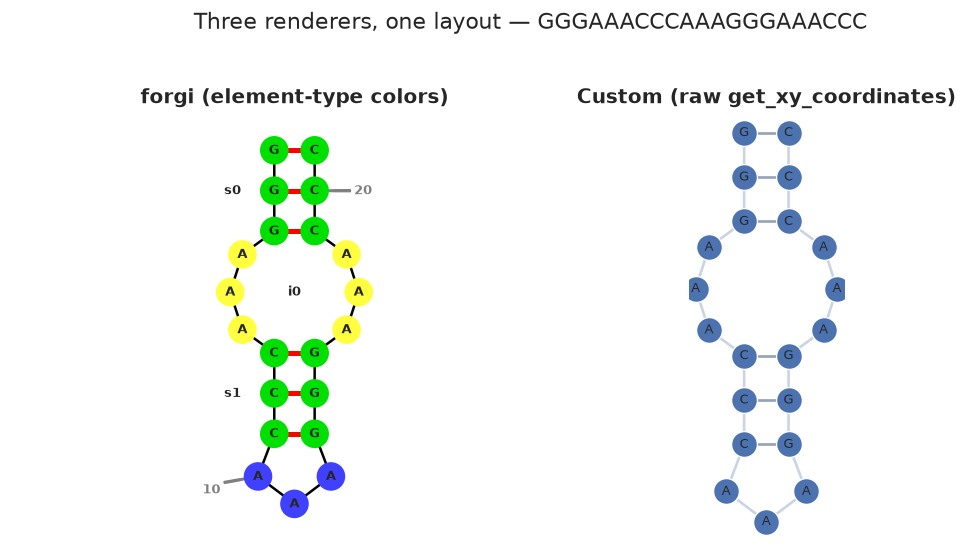

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
plot_forgi_structure(seq_1, structure_1, ax=axes[0], title="forgi (element-type colors)")
plot_custom_structure(seq_1, structure_1, ax=axes[1], title="Custom (raw get_xy_coordinates)")
fig.suptitle(f"Three renderers, one layout — {seq_1}", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the SVG above and the two panels below all trace out the same
double-hairpin layout — the same stems point in the same directions, the same loops
form the same circles. `forgi` adds element-type coloring (stems vs. loops);
`plot_custom_structure` currently uses one flat color, but because it is built from
the raw coordinates returned by `RNA.get_xy_coordinates`, *we* control what each
nucleotide's color (or size, or label) shows. Section 6 puts that control to use.


## 5. Worked example 2 — coloring a structure by pairing probability

`forgi`'s element-type coloring is *categorical*: every nucleotide in a stem gets the
same color, whether that base pair is rock-solid or barely forms. But notebook 03
showed that individual base pairs within the MFE structure can have very different
probabilities in the ensemble — some "fray" at the ends of helices.

We reuse `seq_2` from notebook 03 (the sequence with two competing structures, where
several stem-end pairs are noticeably less certain than the interior pairs) and color
each nucleotide of the MFE diagram by

$$
p_{\text{paired}}(i) = \sum_{j \neq i} p_{ij},
$$

the total probability (from `fc.bpp()`) that position $i$ is paired with *something*
in the ensemble — using the **same coordinate layout** as the MFE structure, so the
picture stays recognizable.


In [ ]:
seq_2 = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"
fc_2 = RNA.fold_compound(seq_2)
structure_2, mfe_2 = fc_2.mfe()
fc_2.pf()
bpp_2 = np.array(fc_2.bpp())  # (n+1) x (n+1), 1-indexed, upper triangle populated

n2 = len(seq_2)
p_paired = np.array([bpp_2[i, :].sum() + bpp_2[:, i].sum() for i in range(1, n2 + 1)])

print(f"{seq_2}\n{structure_2}  ({mfe_2:.2f} kcal/mol)")
print("p_paired by position:")
print(np.round(p_paired, 2))


CCCCAAAAGGGGAAAACCCCAAAAGGGG
((((....))))....((((....))))  (-13.20 kcal/mol)
p_paired by position:
[0.97 1.   1.   0.99 0.   0.   0.   0.   0.99 1.   1.   0.98 0.   0.
 0.   0.   0.98 1.   1.   0.99 0.   0.   0.   0.   0.99 1.   1.   0.95]


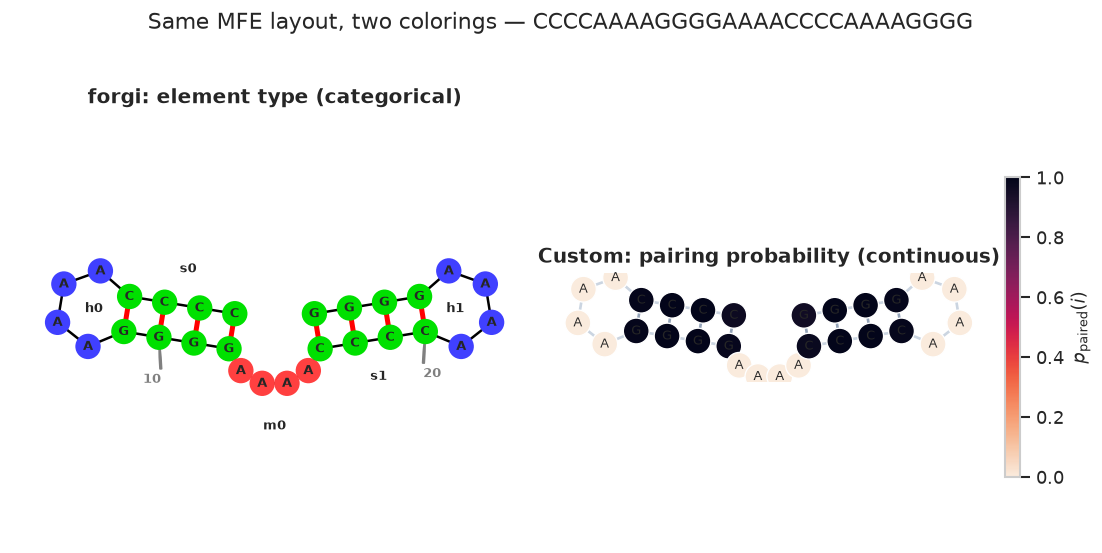

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
plot_forgi_structure(seq_2, structure_2, ax=axes[0], title="forgi: element type (categorical)")
sc = plot_custom_structure(seq_2, structure_2, ax=axes[1], values=p_paired, vmin=0, vmax=1,
                            title="Custom: pairing probability (continuous)",
                            fig=fig, colorbar_label=r"$p_{\mathrm{paired}}(i)$")
fig.suptitle(f"Same MFE layout, two colorings — {seq_2}", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: `forgi` (left) shows every stem nucleotide in the same green —
visually, the two 4-bp helices look equally solid. The probability-colored diagram
(right) tells a different story: the **interior** pairs of each helix are colored at
the top of the scale ($p_{\text{paired}} \approx 1$), while the pairs closest to the
hairpin loops and helix ends are visibly darker/cooler — their probability is spread
over the alternative pairing registers that notebook 03 found for this sequence. The
categorical view answers "what kind of element is this?"; the continuous view answers
"how confident are we that *this exact pair* forms?" — and the two questions can have
different answers for the same nucleotide.


## 6. Worked example 3 — comparing two structures with one arc diagram

`seq_2` has (at least) two low-energy structures: the MFE itself, with two separate
4-bp hairpins, and a close competitor with one hairpin nested inside an extended outer
helix (the "alternative" structure used in notebooks 03 and 05). `fc.subopt(150)`
(an exhaustive search up to 1.5 kcal/mol above the MFE, in units of 0.01 kcal/mol)
finds exactly this pair of structures.

A side-by-side pair of standard arc diagrams would force the reader to mentally align
two separate pictures. `plot_comparative_arcs` instead draws **both structures on one
sequence**: any pair present in *both* structures would be drawn above and below the
backbone in green, pairs unique to the MFE are drawn above in blue, and pairs unique
to the alternative are drawn below in orange.


In [ ]:
subopt_structures = []
seen = set()
for s in fc_2.subopt(150):
    if s.structure not in seen:
        seen.add(s.structure)
        subopt_structures.append((s.structure, s.energy))

for structure, energy in subopt_structures:
    print(f"{structure}  ({energy:.2f} kcal/mol)")

alt_structure_2, alt_energy_2 = subopt_structures[1]


((((....))))....((((....))))  (-13.20 kcal/mol)
((((....((((....))))....))))  (-13.00 kcal/mol)


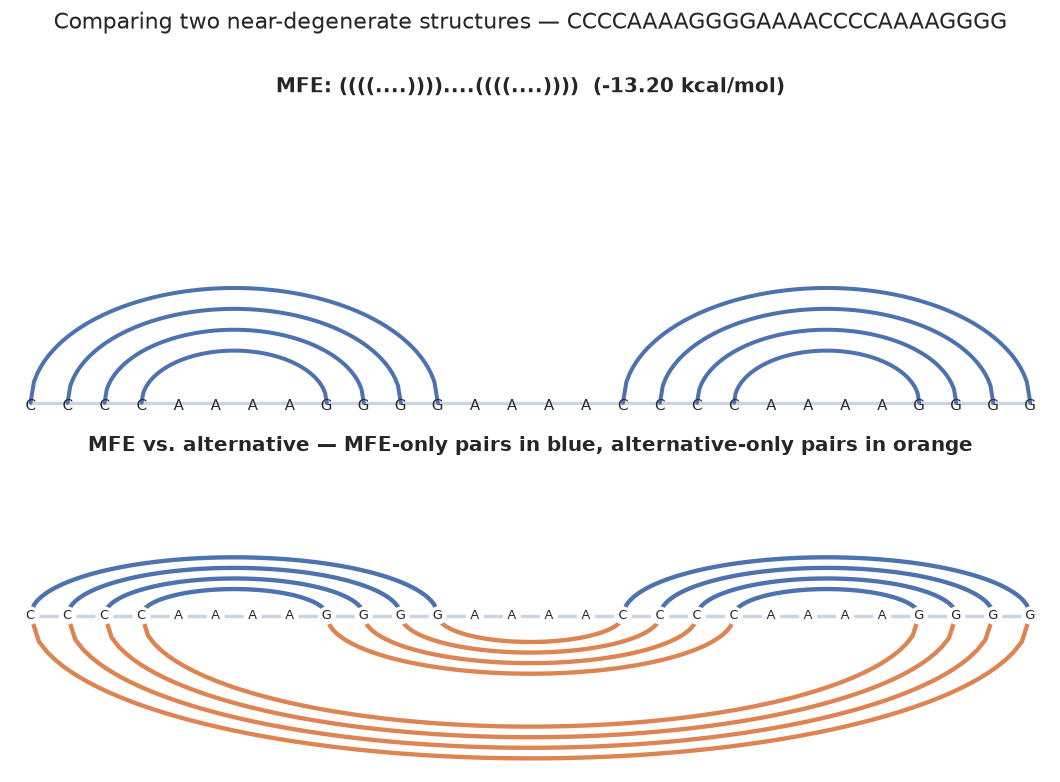

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5))
plot_arc_diagram(seq_2, structure_2, ax=axes[0],
                 title=f"MFE: {structure_2}  ({mfe_2:.2f} kcal/mol)")
plot_comparative_arcs(seq_2, structure_2, alt_structure_2, ax=axes[1],
                      label_a=f"MFE ({mfe_2:.2f})", label_b=f"alternative ({alt_energy_2:.2f})",
                      title=f"MFE vs. alternative — MFE-only pairs in blue, "
                            f"alternative-only pairs in orange")
fig.suptitle(f"Comparing two near-degenerate structures — {seq_2}", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the comparative diagram makes the relationship between the two
structures immediate — and the relationship turns out to be more dramatic than "minor
adjustment". **None** of the eight base pairs are shared (there are no green arcs at
all): every single pair changes its partner. The MFE's two *separate* 4-bp hairpins
(blue arcs, both in the top half) are completely dismantled and rebuilt as one long
*outer* helix connecting the two ends of the molecule plus one *inner* hairpin nested
inside it (orange arcs, both in the bottom half). Despite this total rearrangement —
every nucleotide keeps the same partner *count* (paired vs. unpaired) but swaps *which*
partner it pairs with — the cost is only about 0.2 kcal/mol ($-13.0$ vs. $-13.2$).
This is exactly the trade-off notebook 05 manipulated with hard and soft constraints
on the pair $(1, 28)$: forcing that one pair was enough to flip the molecule from the
"two separate hairpins" topology to the "nested helix" topology seen here — here we
*see* both topologies at once, with no constraints applied at all.


## 7. Case study — a one-sequence visualization "dashboard"

For a final sequence with a slightly more interesting topology — two hairpins joined
through a multiloop — we assemble six panels into a single dashboard figure, the kind
of summary you might keep in a lab notebook for a sequence under active study:

1. **Custom structure diagram** (default coloring) — "what does it look like?"
2. **Probability-colored structure diagram** — "how confident is each pair?"
3. **Arc diagram** — "which positions pair, in sequence order?"
4. **Mountain plot** — "how deep is the nesting, and where are the loops?"
5. **Dot plot** (bpp vs. MFE) — "does the ensemble agree with the MFE?"
6. **Positional entropy** — "where is the ensemble most uncertain?"


In [ ]:
seq_3 = "GGGAAACCCAAAAGGGAAACCCAAAGGGAAACCC"
fc_3 = RNA.fold_compound(seq_3)
structure_3, mfe_3 = fc_3.mfe()
fc_3.pf()
bpp_3 = np.array(fc_3.bpp())
n3 = len(seq_3)
p_paired_3 = np.array([bpp_3[i, :].sum() + bpp_3[:, i].sum() for i in range(1, n3 + 1)])
entropy_3 = np.array(fc_3.positional_entropy())[1:]

print(f"{seq_3}\n{structure_3}  ({mfe_3:.2f} kcal/mol)")


GGGAAACCCAAAAGGGAAACCCAAAGGGAAACCC
(((...(((....)))...)))...(((...)))  (-10.20 kcal/mol)


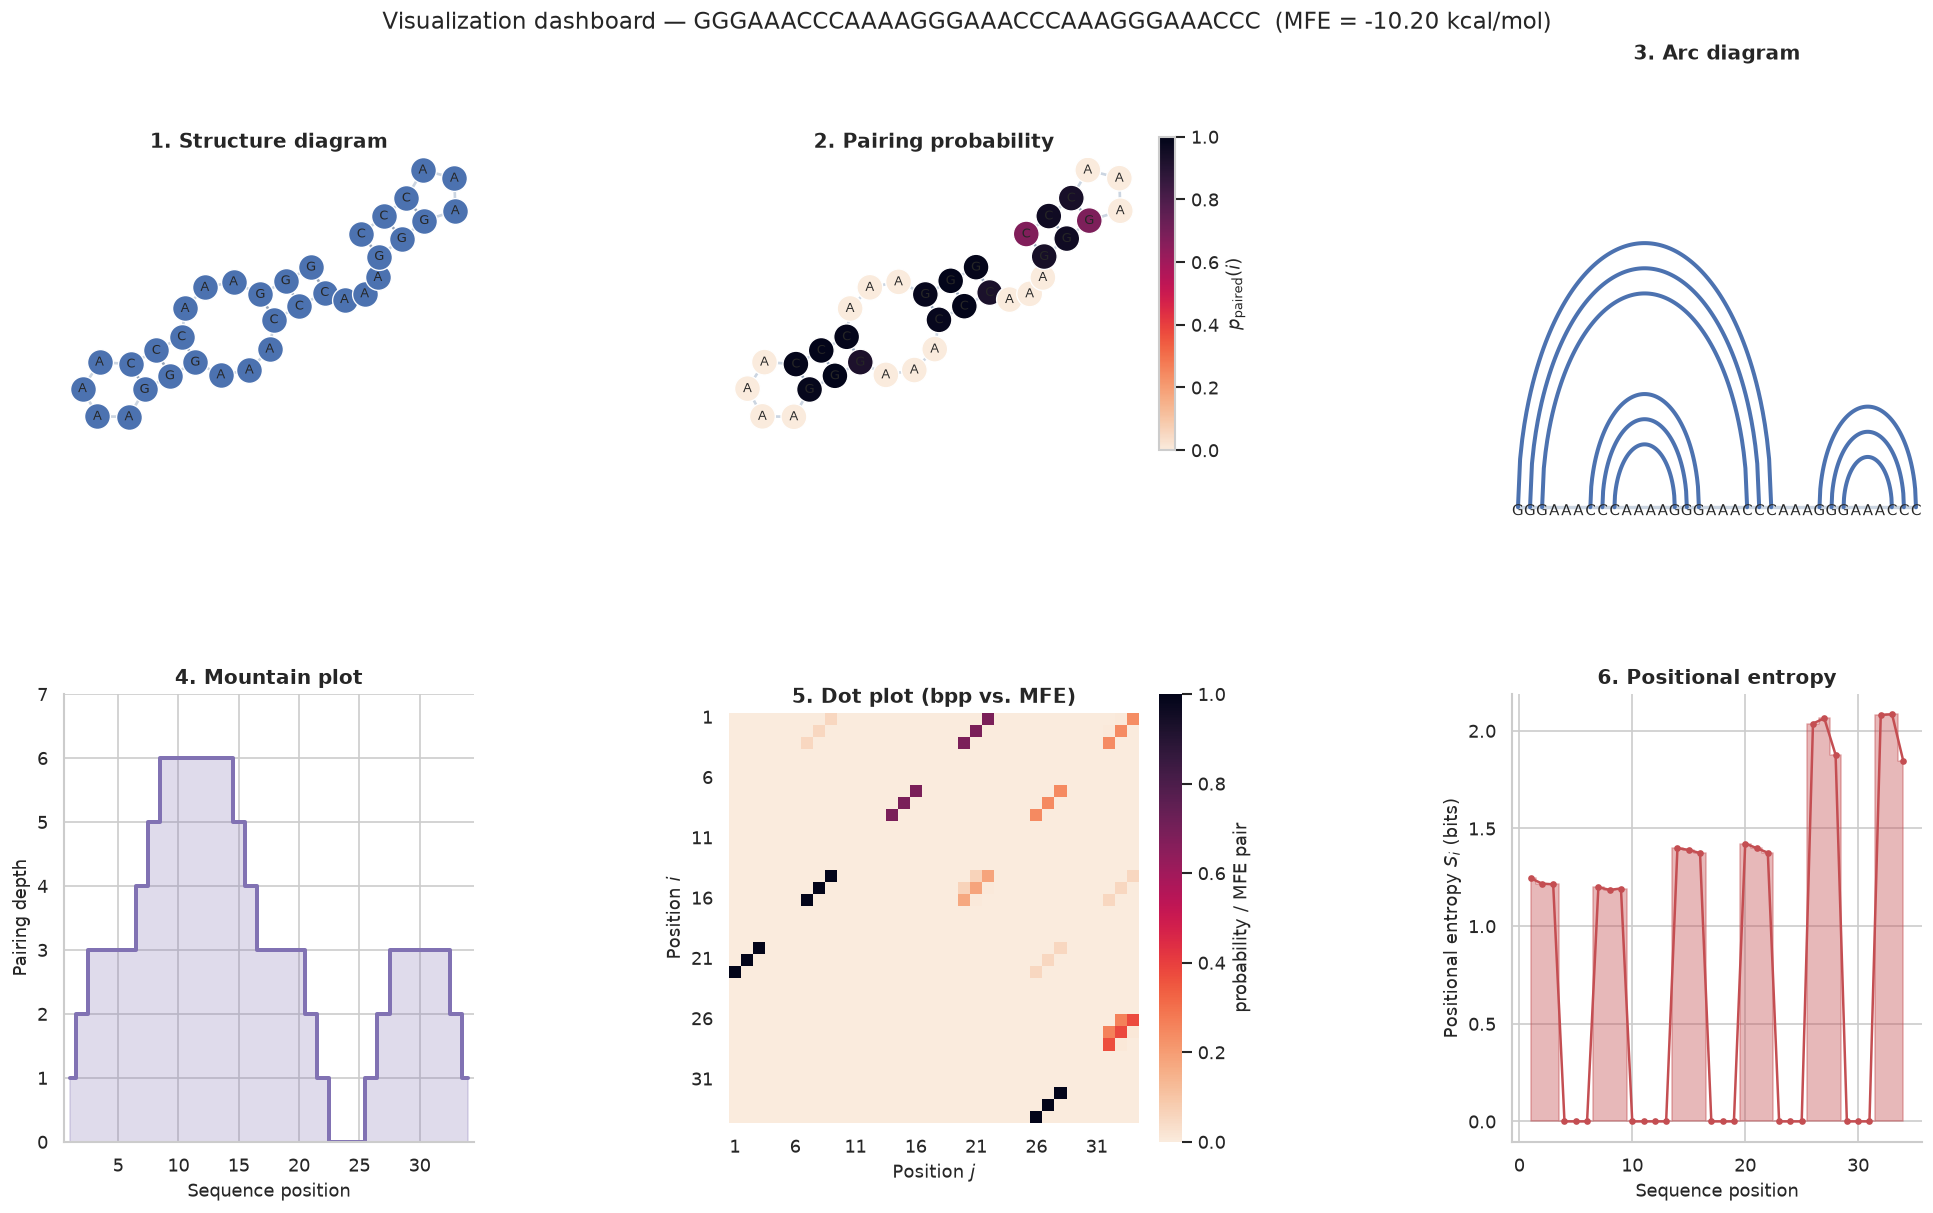

In [ ]:
fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3, hspace=0.25, wspace=0.3)

ax_custom = fig.add_subplot(gs[0, 0])
ax_prob = fig.add_subplot(gs[0, 1])
ax_arc = fig.add_subplot(gs[0, 2])
ax_mountain = fig.add_subplot(gs[1, 0])
ax_dot = fig.add_subplot(gs[1, 1])
ax_entropy = fig.add_subplot(gs[1, 2])

plot_custom_structure(seq_3, structure_3, ax=ax_custom, title="1. Structure diagram")
plot_custom_structure(seq_3, structure_3, ax=ax_prob, values=p_paired_3, vmin=0, vmax=1,
                       fig=fig, colorbar_label=r"$p_{\mathrm{paired}}(i)$",
                       title="2. Pairing probability")
plot_arc_diagram(seq_3, structure_3, ax=ax_arc, title="3. Arc diagram")
plot_mountain(seq_3, structure_3, ax=ax_mountain, title="4. Mountain plot")
plot_dot_plot(seq_3, fc_3, structure_3, ax=ax_dot, title="5. Dot plot (bpp vs. MFE)", tick_step=5)

positions_3 = np.arange(1, n3 + 1)
ax_entropy.fill_between(positions_3, entropy_3, color=PALETTE[3], alpha=0.4, step="mid")
ax_entropy.plot(positions_3, entropy_3, color=PALETTE[3], marker="o", ms=3, lw=1.5)
ax_entropy.set_xlabel("Sequence position")
ax_entropy.set_ylabel(r"Positional entropy $S_i$ (bits)")
ax_entropy.set_title("6. Positional entropy")
sns.despine(ax=ax_entropy)

fig.suptitle(f"Visualization dashboard — {seq_3}  (MFE = {mfe_3:.2f} kcal/mol)", fontsize=14)
plt.show()


**Reading the dashboard**: panels 1, 3, and 4 are three different views of the *same*
MFE structure — three hairpins joined through a shared outer/inner nesting — and
agree with each other (the mountain plot's three "peaks" in panel 4 correspond to the
three hairpins visible in panels 1 and 3). Panel 2 shows that almost every paired
position has $p_{\text{paired}} \approx 1$ — in the ensemble, these positions are
*almost always paired with something*. But panel 6's positional entropy tells a
different story for the **third** hairpin (positions 26–34): its entropy rises to
$\approx 2$ bits, much higher than the first two hairpins ($\approx 1.2$–$1.4$ bits).
Panel 5's dot plot explains why — its upper triangle has visible off-diagonal mass
connecting the third hairpin to the first two, the signature of a **competing
topology** in which the third hairpin's strands pair with the other hairpins instead
of with each other. So panels 2 and 6 are not contradictory: $p_{\text{paired}}$ asks
"is this position paired with *something*?" (almost always, yes), while entropy asks
"is it the *same* partner across the ensemble?" (for the third hairpin, no — multiple
registers compete). This is the same lesson as Section 6, now visible for a single
structure without needing `subopt()` at all: a dashboard like this is exactly how you
would notice that a region "looks" well-folded (panels 1–4) but is actually ambiguous
(panels 5–6), and would know where to focus a `subopt()` search or a constraint.


## 8. Best practices and common pitfalls

- **Indexing**: `RNA.get_xy_coordinates(structure)` is 0-indexed (`xy.get(0)` is
  position 1), while `fc.bpp()` and dot-bracket pairs from `dotbracket_to_pairs` in
  this notebook are 1-indexed. Mixing the two conventions silently shifts every
  nucleotide by one position — always convert at the boundary, as
  `plot_custom_structure` does (`coords[i - 1, 0]`).
- **Don't discard `forgi` — extend it.** `forgi`'s element-type coloring remains the
  fastest way to see *what kind* of structure you have. Reach for raw
  `get_xy_coordinates` only when you need to encode a *continuous* quantity (a
  probability, an experimental reactivity, a conservation score) that a categorical
  palette cannot represent.
- **Match color scale to the quantity.** Probabilities and other bounded $[0, 1]$
  quantities should use `vmin=0, vmax=1` so that colors are comparable *across
  figures*, not just within one. Notebook 06's pscore heatmap, by contrast, needed a
  symmetric, clipped scale (`vmin=-400, vmax=400`) because covariation scores are
  unbounded and signed — there is no single "right" color scale, only one that fits
  the quantity at hand.
- **Comparative diagrams need a shared reference frame.** `plot_comparative_arcs`
  works because both structures describe the *same sequence* in the *same*
  left-to-right order — arcs from either structure land on the same backbone
  positions. The same trick would not directly apply to two *different* sequences
  (as in notebook 06's alignment-based comparisons), which is why that notebook used
  a pscore matrix over alignment columns instead.
- **Dashboards trade detail for overview.** The six-panel dashboard in Section 7 is
  good for a first look or a summary figure, but each panel is necessarily smaller
  than its single-panel counterpart in notebooks 01/03. When you need to read off
  precise numbers (an exact probability, an exact energy), go back to the full-size
  single-panel version or the underlying DataFrame/array.
- **SVG vs. PNG/raster**: `RNA.svg_rna_plot` output is vector graphics — it scales to
  any size without pixelation, which is ideal for figures destined for a paper or
  poster. matplotlib figures saved via `fig.savefig(..., dpi=300)` are a reasonable
  raster alternative when you need the custom coloring from Sections 5–6, which
  `svg_rna_plot` cannot produce.


## 9. Summary

- Every RNA structure picture in this tutorial series — `forgi` diagrams, native SVG,
  and the custom diagrams in this notebook — is built on the same underlying 2D
  layout, exposed directly via `RNA.get_xy_coordinates`.
- That direct access lets you go beyond `forgi`'s categorical element-type coloring:
  Section 5 colored a structure diagram by *continuous* base-pairing probability,
  revealing fraying at helix ends that the categorical view hides.
- A **comparative arc diagram** (Section 6) puts two structures for one sequence on a
  single picture, with shared and structure-specific pairs visually separated —
  useful whenever you have a near-degenerate pair of structures, as from
  `fc.subopt()`.
- A **dashboard** (Section 7) combines several chart types for one sequence into a
  single summary figure; choosing *which* charts to include is itself guided by the
  reference table in Section 2.

**Next**: [10_case_study.ipynb](10_case_study.ipynb) is the final notebook in this
track — an end-to-end analysis of a single sequence that combines MFE folding,
ensemble analysis, constraints, and the visualization techniques from this notebook
into one workflow.


## 10. Exercises

1. **Unpaired probability diagram.** Section 5 colored each nucleotide by
   $p_{\text{paired}}(i)$. Compute $p_{\text{unpaired}}(i) = 1 - p_{\text{paired}}(i)$
   (this is also returned directly as the last row of `fc.bpp()` in some ViennaRNA
   versions, or can be computed as shown here) and redraw `seq_2`'s structure colored
   by this quantity. Which nucleotides light up, and does that match where you would
   expect single-stranded regions?

2. **Three-way comparison.** `fc_2.subopt(300)` (a wider energy window) returns more
   than two distinct structures for `seq_2`. Extend `plot_comparative_arcs` (or call
   it twice) to compare the MFE against *each* additional structure. Do the
   additional structures share the same "core" pairs as the first alternative, or do
   they differ in a new way?

3. **Dashboard for a designed sequence.** Pick one of the sequences from notebook 07
   (the RNA–RNA interaction notebook) and build a similar dashboard for the
   *intramolecular* structure of one strand alone (i.e., without the `&` partner).
   Compare the dashboard's "pairing probability" panel for the lone strand against
   the bpp heatmap notebook 07 produced for the *complex* — which positions change
   the most when the partner strand is present?
